# Clustering

In this notebool, I aim to obtain a set of tickets cluster with description and keywords to be used a labels for trianing a classification model in `2.Classification.ipynb`.

## Plan

1. Explore the tickets structure and content.
2. Convert the tickets into embedding using a local model.
3. Reduce the embeddings dimension via principal component analysis (PCA)
4. Train a HDBSCAN model to obtain clusters without a pre-defined number of clusters.
5. Through a local LLM, obtain a description and keywords for each cluster.
6. Rearrange the clusters set into a smaller and meaninful clusters set interpreting the descriptions, keywords, and cluster elements.

Through this process, we aim to obtain a compreensive and meaninful set of clusters which will work as labels for a classification model.

## Packages and Settings

In [54]:
# Data handling
import hashlib
import re
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

# Text vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from sklearn.metrics import silhouette_score

# Semi-supervised reassignment of the HDBSCAN noise cluster
from sklearn.semi_supervised import LabelSpreading

# Embeddings and dimensionality reduction
import torch
from sentence_transformers import SentenceTransformer

# Plotting
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruno.santos\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [97]:
# Data paths
DATASET_PATH = 'dataset/classificacao_atendimento.csv'

# TOKENS
TOKEN_PATTERN = r"(?u)\b\w\w+\b"
TOKEN_STOPWORDS = stopwords.words("portuguese")
ANGLE_BRACKETS_REGEX = re.compile(r"<[^<>\n]{1,60}>")

# Display
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 90)
DISPLAY_STRING_LIMIT = 5000


Auxiliar methods

In [124]:
def display_dataframe_as_markdown(df, maxcolwidths=50):
    """
    Display a pandas DataFrame as a markdown table with limited column widths.
    """   
    print(df.to_markdown(maxcolwidths=maxcolwidths)[:DISPLAY_STRING_LIMIT])

## Read tickets

In [ ]:
tickets_df = pd.read_csv(
    DATASET_PATH, 
    sep=',', 
    encoding='utf-8')

if tickets_df["ticket_id"].is_unique:
    tickets_df.set_index("ticket_id", inplace=True)

NUMBER_TICKETS = len(tickets_df)

tickets_df

,ticket_id,subject,body
0,2,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>,\n\nEstou escrevendo para trazer à sua atenção um pr..."
1,28,Problemas intermitentes de exibição após atualização de firmware,"Caro Suporte ao Cliente,\n\n Estou entrando em contato para relatar um problema com me..."
2,45,Pedido de Assistência para Administração de Servidores,"Prezado Suporte ao Cliente de Serviços de TI,\n\nEspero que esta mensagem o encontre b..."
3,46,NaN,"Prezado <name>,\n\nSentimos muito ao saber sobre o atraso na entrega do seu Apple Watc..."
4,63,Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual,"Prezado Atendimento ao Cliente,<br><br>Recentemente adquiri um MacBook Air M1 em sua l..."
...,...,...,...
468,3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que esta mensagem o encontre bem. Estou esc..."
469,3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEstou entrando em contato para relatar uma ..."
470,3988,Problema de Cobrança: Cobranças Incorretas na Assinatura,"Caro Equipe de Suporte ao Cliente,\n\nEstou escrevendo para trazer à sua atenção uma d..."
471,3994,Assistência Necessária para Problema de Tela do Dell XPS 13,"Caro Time de Suporte ao Cliente, estou enfrentando um problema de cintilação na tela d..."


In [6]:
tickets_df.info()

<class 'pandas.DataFrame'>
Index: 473 entries, 2 to 3996
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   subject  419 non-null    str  
 1   body     473 non-null    str  
dtypes: str(2)
memory usage: 406.5 KB


## Clean tokens

Before embedding or clustering anything, we separate the tickets parts with the core information (*what the customer needs*) from the noise parts that repeat across multiple messages. Very frequent words such as `obrigado` and `atenciosamente` across the tickets buried the core message and only add noise for clustering.

The analysis proceeds in the following steps:

1. **Tokens length analysis**
2. **Structural noise analysis**
3. **Terms frequency analysis**
4. **Phrasal frequency analysis**
5. **Text cleaning**
6. **Qualitative validation**

### Tokens length analysis

Merge `subject` and `body` into the `full_text` column.

In [86]:
cleaned_tickets_df = tickets_df.copy()

cleaned_tickets_df["subject"] = (
    cleaned_tickets_df["subject"]
    .fillna("")
    .str
    .strip()
)

cleaned_tickets_df["body"] = (
    cleaned_tickets_df["body"]
    .fillna("")
    .str
    .strip()
)

cleaned_tickets_df["full_text"] = (
    cleaned_tickets_df.apply(
        lambda row: row["body"] if (row["subject"] == "") else (row["subject"] + ". " + row["body"]), 
        axis=1
    )
)

cleaned_tickets_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ticket_id  473 non-null    int64
 1   subject    473 non-null    str  
 2   body       473 non-null    str  
 3   full_text  473 non-null    str  
dtypes: int64(1), str(3)
memory usage: 806.6 KB


In [89]:
display_dataframe_as_markdown(cleaned_tickets_df)

|     |   ticket_id | subject                                            | body                                               | full_text                                          |
|----:|------------:|:---------------------------------------------------|:---------------------------------------------------|:---------------------------------------------------|
|   0 |           2 | Erro na Autocompletação de Código do IntelliJ IDEA | Prezado Suporte ao Cliente <name>,                 | Erro na Autocompletação de Código do IntelliJ      |
|     |             |                                                    | Estou escrevendo para trazer à sua atenção um      | IDEA. Prezado Suporte ao Cliente <name>,           |
|     |             |                                                    | problema recorrente com o recurso de               | Estou escrevendo para trazer à sua atenção um      |
|     |             |                                                    | autocompletação de c

Characters and tokens box-plot

<Figure size 640x480 with 0 Axes>

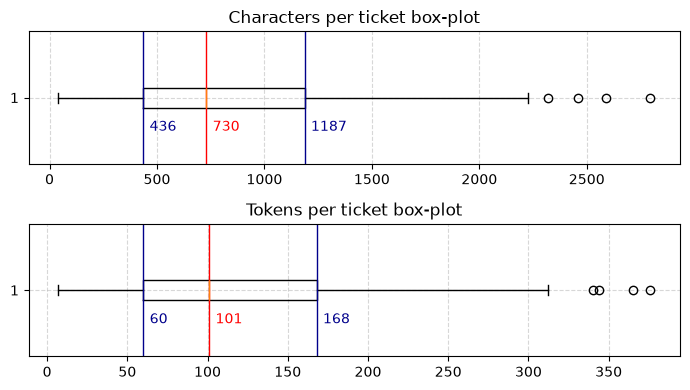

In [9]:
chars = cleaned_tickets_df["full_text"].str.len()
tokens = cleaned_tickets_df["full_text"].str.split(" ").str.len()

plt.clf()
fig, axs = plt.subplots(2, 1, figsize=(7, 4))

# Characters per ticket box-plot
axs[0].set_title("Characters per ticket box-plot")
axs[0].boxplot(chars, orientation="horizontal")
axs[0].grid(linestyle="--", alpha=0.5)

median_chars = chars.median()
axs[0].axvline(median_chars, color="red", linestyle="-", linewidth=1)
axs[0].text(median_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{median_chars:.0f}", color="red")

percentile_25_chars = chars.quantile(0.25)
axs[0].axvline(percentile_25_chars, color="darkblue", linestyle="-", linewidth=1)
axs[0].text(percentile_25_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{percentile_25_chars:.0f}", color="darkblue")

percentile_75_chars = chars.quantile(0.75)
axs[0].axvline(percentile_75_chars, color="darkblue", linestyle="-", linewidth=1)
axs[0].text(percentile_75_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{percentile_75_chars:.0f}", color="darkblue")

# Tokens per ticket box-plot
axs[1].set_title("Tokens per ticket box-plot")
axs[1].boxplot(tokens, orientation="horizontal")
axs[1].grid(linestyle="--", alpha=0.5)

median_tokens = tokens.median()
axs[1].axvline(median_tokens, color="red", linestyle="-", linewidth=1)
axs[1].text(median_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{median_tokens:.0f}", color="red")

percentile_25_tokens = tokens.quantile(0.25)
axs[1].axvline(percentile_25_tokens, color="darkblue", linestyle="-", linewidth=1)
axs[1].text(percentile_25_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{percentile_25_tokens:.0f}", color="darkblue")

percentile_75_tokens = tokens.quantile(0.75)
axs[1].axvline(percentile_75_tokens, color="darkblue", linestyle="-", linewidth=1)
axs[1].text(percentile_75_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{percentile_75_tokens:.0f}", color="darkblue")

plt.tight_layout()
plt.savefig("images/boxplot_chars_tokens.png", dpi=300)
plt.show()

Characters and tokens distribution

<Figure size 640x480 with 0 Axes>

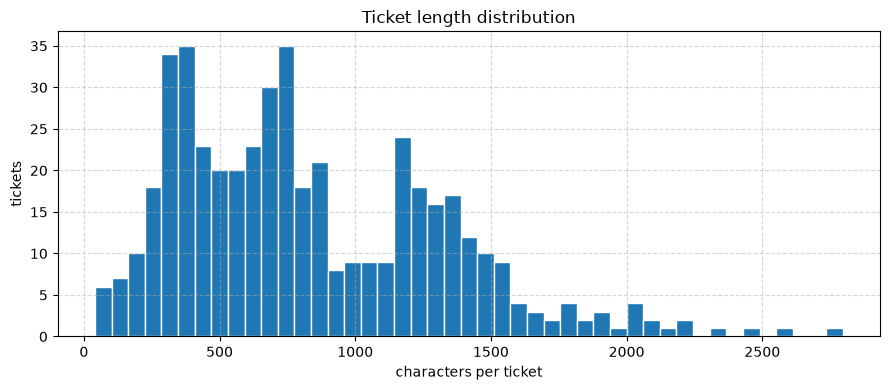

In [96]:
plt.clf()
fig, ax = plt.subplots(figsize=(9, 4))

# Characters distribution
ax.hist(cleaned_tickets_df["full_text"].str.len(), bins=45, color="tab:blue", edgecolor="white")
ax.set_xlabel("characters per ticket")
ax.set_ylabel("tickets")
ax.set_title("Ticket length distribution")
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("images/histogram_chars.png", dpi=300)
plt.show()

### Structural noise analysis

Some noise is not a vocabulary problem: anonymisation, placeholders, HTML markup, and malformed rows.

In [ ]:
angle_brackets = cleaned_tickets_df["full_text"].map(ANGLE_BRACKETS_REGEX.findall)
brackets_counter = Counter([s.lower() for brackets in angle_brackets for s in brackets])
br_brackets_counter = Counter([s.lower() for brackets in angle_brackets for s in brackets if not s.lower().startswith("<br")])
tickets_with_multiple_brackets = angle_brackets.map(lambda s: len(s) > 0).sum()

print(f"""
Structural noise:
    angle brackets count: {brackets_counter.total()}
    angle brackets (not <br>) count: {br_brackets_counter.total()}
    tickets containing >=1 angle brackets: {tickets_with_multiple_brackets} / {NUMBER_TICKETS}
""")


Structural noise:
    angle brackets count: 1227
    angle brackets (not <br>) count: 1155
    tickets containing >=1 angle brackets: 447 / 473



In [118]:
print("Most common brackets:")
for bracket, count in brackets_counter.most_common(10):
    print(f"    {bracket:<30}{count:<5}")

Most common brackets:
    <name>                        530  
    <tel_num>                     263  
    <acc_num>                     197  
    <br>                          72   
    <email>                       43   
    <company_name>                20   
    <email_address>               18   
    <company>                     12   
    <position>                    10   
    <order_num>                   10   


In [125]:
# Malformed bodies: one ticket stores its content as a JSON string.
json_bodies = cleaned_tickets_df["body"][cleaned_tickets_df["body"].str.startswith(("{", "["))]

cleaned_tickets_df.loc[cleaned_tickets_df["body"].str.startswith(("{", "[")), "body"]

print(f"Bodies that are JSON rather than prose: {len(json_bodies)}")
for tid, text in json_bodies.items():
    print(f"  ticket {tid}: {text[:110]}...")

display_dataframe_as_markdown(
    cleaned_tickets_df
    .loc[
        cleaned_tickets_df["body"]
        .str.startswith(("{", "[")), "body"
    ]
    ,maxcolwidths=100
)

Bodies that are JSON rather than prose: 1
  ticket 377: {"greeting": "Caro Suporte ao Cliente,", "body": "Preciso de detalhes sobre o recurso de teclado destacável e ...
|     | body                                                                                                |
|----:|:----------------------------------------------------------------------------------------------------|
| 377 | {"greeting": "Caro Suporte ao Cliente,", "body": "Preciso de detalhes sobre o recurso de teclado    |
|     | destacável e compatibilidade com o Windows 10 para o Microsoft Surface Pro 7. Você poderia fornecer |
|     | mais informações?", "closing": "Obrigado, <name>"}                                                  |


In [137]:
# Very short tickets: little signal, worth tracking downstream.
short_tickest = (
    cleaned_tickets_df
    .where(cleaned_tickets_df["full_text"].str.len() < 100)
    .dropna(subset=["full_text"])
    .sort_values(by="full_text", key=lambda s: s.str.len())
)
short_tickest["length"] = short_tickest["full_text"].str.len()

print(f"\nTickets under 100 characters: {len(short_tickest)}\n")
display_dataframe_as_markdown(short_tickest[["length", "full_text"]], maxcolwidths=100)


Tickets under 100 characters: 6

|     |   length | full_text                                                                                     |
|----:|---------:|:----------------------------------------------------------------------------------------------|
| 268 |       41 | O software fica sem resposta ao exportar.                                                     |
| 457 |       43 | Por favor, reduza a interrupção do serviço.                                                   |
| 325 |       45 | Melhorar a eficiência do sistema de tíquetes.                                                 |
| 448 |       59 | Problema com Anexo do Ticket. Precisa de resolução no Jira.                                   |
| 421 |       90 | Preciso de assistência urgente com problemas de implantação e otimização de custos da AWS.    |
|  62 |       93 | Problema com erro de assinatura. Não conseguimos acessar o e-mail e o Excel na última semana. |


### Terms frequency analysis

In [147]:
token_counter = CountVectorizer(
    binary=True,
    token_pattern=TOKEN_PATTERN
)

tokens_matrix = token_counter.fit_transform(cleaned_tickets_df["full_text"])
vocabulary = token_counter.get_feature_names_out()
tokens_frequency = np.asarray(tokens_matrix.sum(axis=0)).ravel() / NUMBER_DOCS
tokens_frequency_order = np.argsort(-tokens_frequency)

Terms frequency

In [148]:
terms_frequency = pd.DataFrame({
    "term": vocabulary[tokens_frequency_order], 
    "frequency": tokens_frequency[tokens_frequency_order]
})
terms_frequency.index = np.arange(1, len(terms_frequency) + 1)

terms_frequency

,term,frequency
1,de,0.970402
2,name,0.934461
3,suporte,0.892178
4,para,0.871036
5,estou,0.797040
...,...,...
3381,dê,0.002114
3382,895,0.002114
3383,18,0.002114
3384,ões,0.002114


Terms frequency decay plot

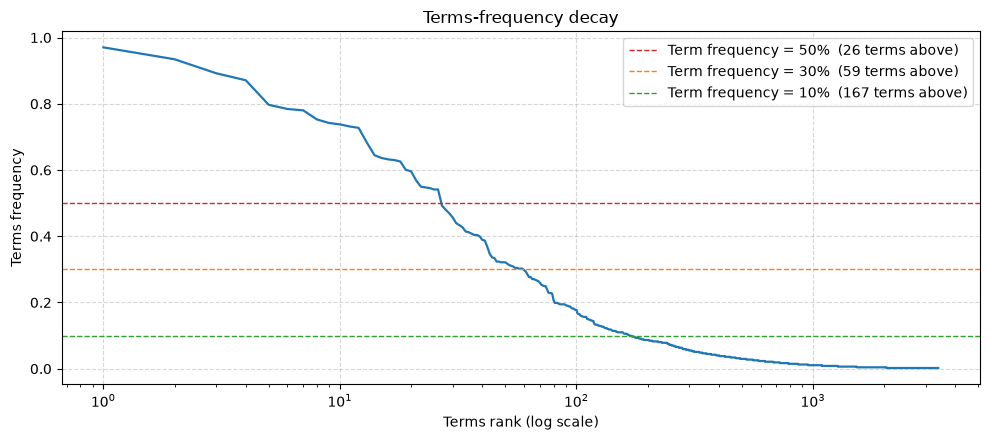

In [149]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(np.arange(1, len(terms_frequency) + 1), np.sort(terms_frequency["frequency"])[::-1], lw=1.6)
ax.set_xscale("log")
for threshold, colour in [(0.5, "tab:red"), (0.3, "tab:orange"), (0.1, "tab:green")]:
    ax.axhline(threshold, ls="--", lw=1, color=colour,
               label=f"Term frequency = {threshold:.0%}  ({(terms_frequency['frequency'] > threshold).sum()} terms above)")
ax.set_xlabel("Terms rank (log scale)")
ax.set_ylabel("Terms frequency")
ax.set_title("Terms-frequency decay")
ax.grid(linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("images/terms_frequency_decay.png", dpi=300)
plt.show()

### Phrase frequency analysis

Terms frequency understates the problem. The real noise in these tickets relies on phrases (*"espero que esta mensagem o encontre bem"*, *"aguardo sua resposta rápida"*).

In [154]:
phrase_counter = CountVectorizer(
    binary=True,
    ngram_range=(3,20), # Phrases of 3 to 20 words
    token_pattern=TOKEN_PATTERN
)

phrases_matrix = phrase_counter.fit_transform(cleaned_tickets_df["full_text"])
phrases = phrase_counter.get_feature_names_out()
phrases_frequency = np.asarray(phrases_matrix.sum(axis=0)).ravel() / NUMBER_TICKETS
phrases_frequency_order = np.argsort(-phrases_frequency)

In [155]:
phrases_frequency_df = pd.DataFrame({
    "term": phrases[phrases_frequency_order], 
    "frequency": phrases_frequency[phrases_frequency_order]
})
phrases_frequency_df.index = np.arange(1, len(phrases_frequency_df) + 1)

phrases_frequency_df

,term,frequency
1,suporte ao cliente,0.668076
2,estou escrevendo para,0.467230
3,obrigado pela sua,0.454545
4,que esta mensagem,0.295983
5,espero que esta mensagem,0.295983
...,...,...
798086,útil ter uma visão geral de quaisquer problemas conhecidos relacionados este modelo ou...,0.002114
798087,útil ter uma visão geral de quaisquer problemas conhecidos relacionados este modelo ou...,0.002114
798088,útil ter uma visão geral de quaisquer problemas conhecidos relacionados este modelo ou...,0.002114
798089,útil ter uma visão geral de quaisquer problemas conhecidos relacionados este modelo ou...,0.002114


Knowing *what* the noise is does not yet tell us how to remove it safely. A global find-and-replace for `"obrigado"` would also delete it from a sentence like *"Obrigado pela ajuda até agora, mas o problema continua"*, destroying real content.

Measure **where** each noise family occurs, as a fraction of document length. If greetings
usually are located at the beggining of the ticket, signoffs in the end, and genuine signal spreads through the middle, then positional rules (cut the first line, cut from the signoff in the end) are both safer and simpler than global substitution. A signal control (`problema|erro|falha`) is included for contrast.

In [158]:
# Probe families of boilerplate, plus one genuine-signal control for contrast.
PROBES = {
    "greeting: caro/prezado + suporte":   r"(?i)\b(caro|cara|prezad[oa]s?)\b[^.\n]{0,60}\b(suporte|atendimento|equipe|time|cliente)\b",
    "greeting: olá/saudações":            r"(?i)^\s*(ol[áa]|sauda[çc][õo]es)\b",
    "pleasantry: espero...encontre bem":  r"(?i)espero que (esta|este)[^.]{0,40}encontre[^.]{0,20}bem",
    "pleasantry: aguardo sua resposta":   r"(?i)aguard(o|ando|amos)[^.]{0,30}resposta",
    "pleasantry: obrigado pela atenção":  r"(?i)obrigad[oa][^.]{0,40}aten[çc][ãa]o",
    "signoff: atenciosamente":            r"(?i)\batenciosamente\b",
    "signoff: cordialmente/cumprimentos": r"(?i)\b(cordialmente|melhores cumprimentos|atentamente)\b",
    "closing: obrigado (standalone)":     r"(?i)\bobrigad[oa]\b",
    "placeholder: <name> etc":            r"<[^<>\n]{1,60}>",
    "CONTROL - signal: problema/erro":    r"(?i)\b(problema|erro|falha|defeito)\b",
}

positions, rows = {}, []
for label, pattern in PROBES.items():
    rx = re.compile(pattern, re.M)
    found, n_tickets = [], 0

    for text in cleaned_tickets_df["full_text"]:
        matches = list(rx.finditer(text))
        if matches:
            n_tickets += 1
            found.extend(m.start() / len(text) for m in matches)
    if not found:
        continue

    found = np.array(found)
    positions[label] = found
    rows.append({
        "probe": label, 
        "tickets": n_tickets, 
        "freq": n_tickets / NUMBER_TICKETS,
        "median_pos": np.median(found),
        "first_15%": (found < 0.15).mean(), 
        "last_25%": (found > 0.75).mean()
    })

display_dataframe_as_markdown(pd.DataFrame(rows))

|    | probe                              |   tickets |       freq |   median_pos |   first_15% |   last_25% |
|---:|:-----------------------------------|----------:|-----------:|-------------:|------------:|-----------:|
|  0 | greeting: caro/prezado + suporte   |       391 | 0.826638   |    0.0608496 |   0.936061  |   0        |
|  1 | greeting: olá/saudações            |         3 | 0.00634249 |    0         |   1         |   0        |
|  2 | pleasantry: espero...encontre bem  |       148 | 0.312896   |    0.0776153 |   0.945946  |   0        |
|  3 | pleasantry: aguardo sua resposta   |        89 | 0.188161   |    0.915683  |   0         |   1        |
|  4 | pleasantry: obrigado pela atenção  |       150 | 0.317125   |    0.903008  |   0         |   1        |
|  5 | signoff: atenciosamente            |       344 | 0.727273   |    0.966276  |   0         |   1        |
|  6 | signoff: cordialmente/cumprimentos |        12 | 0.02537    |    0.940507  |   0         |   1        |
|

Plot phrasal noise locations

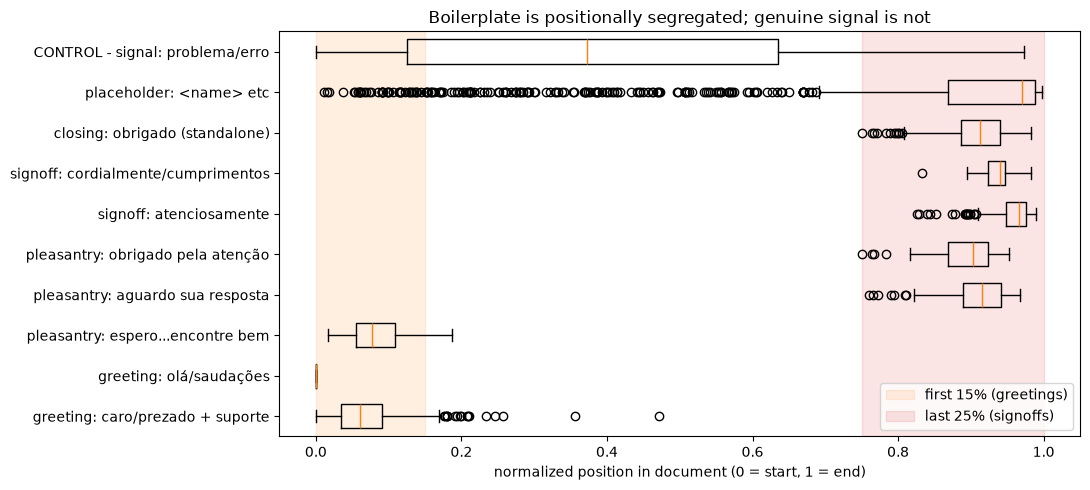

In [159]:
fig, ax = plt.subplots(figsize=(11, 5))

labels = list(positions)
ax.boxplot([positions[l] for l in labels], orientation="horizontal",
           tick_labels=labels, widths=.6)
ax.axvspan(0, 0.15, color="tab:orange", alpha=.12, label="first 15% (greetings)")
ax.axvspan(0.75, 1.0, color="tab:red", alpha=.12, label="last 25% (signoffs)")
ax.set_xlabel("normalized position in document (0 = start, 1 = end)")
ax.set_title("Boilerplate is positionally segregated; genuine signal is not")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("images/phrasal_noise_positions.png", dpi=300)
plt.show()

### Text cleaning

Every rule below traces to a measurement made above — nothing is included on intuition alone.

| # | Rule | Type | Evidence |
|---|---|---|---|
| 1 | Unwrap JSON-encoded bodies | structural | 1 ticket (3299) stores prose inside a JSON string |
| 2 | Replace `<br>` with newline | structural | 72 tags across 7 tickets |
| 3 | Remove angle brackets | structural | 1,155 spans; `name` has frequency of 93.4%, `tel_num` 54.5%, `acc_num` 41.4% |
| 4 | Remove signoffs marker | positional | signoff median position 0.966 |
| 5 | Remove greetings | positional | greeting median position 0.061, 93.6% in first 15% |
| 6 | Remove pleasantry | phrasal | `espero...encontre bem` freq 31.3%, `obrigado pela atenção` freq 31.7% |

Auxiliary methods

The rules are implemented in [`ticket_cleaning.py`](ticket_cleaning.py) so the classification
notebook cleans new tickets with exactly the same code. Each pattern there is annotated with the
measurement above that justifies it.

In [180]:
from ticket_cleaning import (
    PLACEHOLDER_RE, 
    HTML_BR_RE, 
    unwrap_json_body, 
    tidy_punctuation,
    clean_subject, 
    clean_body, 
    clean_ticket)

Apply rules

In [181]:
cleaned_tickets_df["cleaned_subject"] = cleaned_tickets_df["subject"].map(clean_subject)
cleaned_tickets_df["cleaned_body"] = cleaned_tickets_df["body"].map(clean_body)
cleaned_tickets_df["cleaned_full_text"] = cleaned_tickets_df.apply(lambda row: clean_ticket(row["subject"], row["body"]), axis=1)

display_dataframe_as_markdown(cleaned_tickets_df)

|     |   ticket_id | subject                                            | body                                               | full_text                                          | cleaned_subject                                    | cleaned_body                                       | cleaned_full_text                                  |
|----:|------------:|:---------------------------------------------------|:---------------------------------------------------|:---------------------------------------------------|:---------------------------------------------------|:---------------------------------------------------|:---------------------------------------------------|
|   0 |           2 | Erro na Autocompletação de Código do IntelliJ IDEA | Prezado Suporte ao Cliente <name>,                 | Erro na Autocompletação de Código do IntelliJ      | Erro na Autocompletação de Código do IntelliJ IDEA | Estou escrevendo para trazer à sua atenção um      | Erro na Autocompletação de Código

Cleaning impact

In [182]:
def corpus_profile(series, stopwords=None):
    """Measure how much noise remains and how separable the documents are."""
    counts = (
        CountVectorizer(
            binary=True, 
            token_pattern=TOKEN_PATTERN,
            stop_words=stopwords)
        .fit_transform(series)
    )

    ticket_frac = np.asarray(counts.sum(axis=0)).ravel() / counts.shape[0]

    return {
        "vocab": counts.shape[1],
        "freq>0.5": int((ticket_frac > 0.5).sum()),
        "freq>0.3": int((ticket_frac > 0.3).sum()),
        "freq>0.1": int((ticket_frac > 0.1).sum()),
        "mean_chars": series.str.len().mean()
    }


impact = pd.DataFrame({
    "1. raw (subject + body)": corpus_profile(cleaned_tickets_df["full_text"]),
    "2. + text cleaning": corpus_profile(cleaned_tickets_df["cleaned_full_text"]),
    "3. + stopword removal": corpus_profile(cleaned_tickets_df["cleaned_full_text"], TOKEN_STOPWORDS),
}).T
impact["char_reduction"] = 1 - impact["mean_chars"] / impact.iloc[0]["mean_chars"]

display_dataframe_as_markdown(impact)

|                         |   vocab |   freq>0.5 |   freq>0.3 |   freq>0.1 |   mean_chars |   char_reduction |
|:------------------------|--------:|-----------:|-----------:|-----------:|-------------:|-----------------:|
| 1. raw (subject + body) |    3385 |         26 |         59 |        167 |      834.474 |         0        |
| 2. + text cleaning      |    3324 |         14 |         36 |        137 |      687.04  |         0.176678 |
| 3. + stopword removal   |    3202 |          1 |          9 |         88 |      687.04  |         0.176678 |


In [183]:
# What signal survives? Top terms after cleaning AND stopword removal.
signal_vec = TfidfVectorizer(
    sublinear_tf=True, 
    min_df=2, 
    ngram_range=(1, 2),
    token_pattern=TOKEN_PATTERN, 
    stop_words=TOKEN_STOPWORDS)

signal_mat = signal_vec.fit_transform(cleaned_tickets_df["cleaned_full_text"])
signal_terms = np.array(signal_vec.get_feature_names_out())
signal_weight = np.asarray(signal_mat.mean(axis=0)).ravel()

print("Top 30 TF-IDF terms after cleaning + stopword removal:\n")
for rank, i in enumerate(np.argsort(-signal_weight)[:10], start=1):
    print(f"  {rank:>2}. {signal_terms[i]:<28}{signal_weight[i]:.4f}")

Top 30 TF-IDF terms after cleaning + stopword removal:

   1. problema                    0.0384
   2. problemas                   0.0277
   3. sobre                       0.0248
   4. assistência                 0.0235
   5. favor                       0.0235
   6. aws                         0.0233
   7. serviço                     0.0203
   8. urgente                     0.0201
   9. enfrentando                 0.0201
  10. escrevendo                  0.0196


## Embeddings

Turn each cleaned ticket into a dense vector, so that two similar tickets are represent by close vectors even when they are not composed of the same words, for instance *"o roteador cai toda hora"* and *"quedas frequentes de conexão no ISR4331"*.

### Model options

| Model | Params | Dim | PT-BR | Notes |
|---|---|---|---|---|
| **`intfloat/multilingual-e5-large`** | 560M | 1024 | excellent | Strong on clustering benchmarks; needs a prefix |
| `intfloat/multilingual-e5-base` | 278M | 768 | very good | Half the size, ~3× faster, same prefix rule |
| `BAAI/bge-m3` | 568M | 1024 | excellent | Retrieval-tuned; no prefix; 8k-token window |
| `Qwen/Qwen3-Embedding-0.6B` | 600M | 1024 | excellent | Newest; decoder-based, slower on CPU |

### Chosen model

`multilingual-e5-large`:
- Best multilingual model on clustering tasks with a good representation for Portuguese.
- Although it is twice larger than `e5-base`, its quality is better. Since the amount of tokens are short, the model will not take a long time to process the embeddings.

In [184]:
EMBEDDING_MODELS = {
    "intfloat/multilingual-e5-large": {"prefix": "query: ", "passage_prefix": "passage: ", "dim": 1024},
    "intfloat/multilingual-e5-base":  {"prefix": "query: ", "passage_prefix": "passage: ", "dim": 768},
    "BAAI/bge-m3":                    {"prefix": "",        "passage_prefix": "",          "dim": 1024},
    "Qwen/Qwen3-Embedding-0.6B":      {"prefix": "",        "passage_prefix": "",          "dim": 1024},
}

EMBEDDING_MODEL = "intfloat/multilingual-e5-large"
EMBEDDING_PREFIX = EMBEDDING_MODELS[EMBEDDING_MODEL]["prefix"]
EMBEDDING_PASSAGE_PREFIX = EMBEDDING_MODELS[EMBEDDING_MODEL]["passage_prefix"]
EMBEDDING_BATCH_SIZE = 16
EMBEDDINGS_DIR = Path("dataset/embeddings")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"model : {EMBEDDING_MODEL}")
print(f"prefix: {EMBEDDING_PREFIX!r} (symmetric) / {EMBEDDING_PASSAGE_PREFIX!r} (passage)")
print(f"device: {DEVICE}  (torch {torch.__version__})")


model : intfloat/multilingual-e5-large
prefix: 'query: ' (symmetric) / 'passage: ' (passage)
device: cuda  (torch 2.14.0+cu130)


### Generate embeddings

Auxiliary methods

In [185]:
_model_cache = {}

def get_model(model_name):
    """Load a sentence-transformers model once per kernel and reuse it."""
    if model_name not in _model_cache:
        _model_cache[model_name] = SentenceTransformer(model_name, device=DEVICE)
    return _model_cache[model_name]


def embed_documents(
        texts, 
        model_name, 
        prefix="", 
        cache_dir=EMBEDDINGS_DIR,
        batch_size=EMBEDDING_BATCH_SIZE):
    """Encode texts into L2-normalised float32 vectors and cache them on disk.

    The cache key hashes the texts themselves together with the model name and prefix,
    so a change to the cleaning rules invalidates stale embeddings automatically instead
    of silently reusing them. Returns one row per input text, in input order.
    """
    texts = list(texts)
    digest = hashlib.sha1(("\n".join(texts) + model_name + prefix).encode("utf-8")).hexdigest()[:10]
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{model_name.replace('/', '__')}__{len(texts)}__hash__{digest}.npy"

    if cache_path.exists():
        vectors = np.load(cache_path)
        print(f"loaded {vectors.shape} from cache -> {cache_path.name}")
        return vectors

    model = get_model(model_name)
    started = time.perf_counter()
    vectors = model.encode(
        [prefix + t for t in texts],
        batch_size=batch_size,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True).astype(np.float32)
    
    np.save(cache_path, vectors)
    print(f"encoded {vectors.shape} in {time.perf_counter() - started:.0f}s on {DEVICE} "
          f"-> cached to {cache_path.name}")
    
    return vectors

Process embeddings

In [186]:
ticket_embeddings = embed_documents(cleaned_tickets_df["cleaned_full_text"], EMBEDDING_MODEL, prefix=EMBEDDING_PREFIX)

# --- Sanity checks -----------------------------------------------------------
expected_dim = EMBEDDING_MODELS[EMBEDDING_MODEL]["dim"]
assert ticket_embeddings.shape == (NUMBER_TICKETS, expected_dim), ticket_embeddings.shape
assert not np.isnan(ticket_embeddings).any(), "NaNs in embeddings"
norms = np.linalg.norm(ticket_embeddings, axis=1)
assert np.allclose(norms, 1.0, atol=1e-4), "vectors must be unit-norm so cosine == dot product"

# How many tickets exceed the model's context window and get truncated?
model = get_model(EMBEDDING_MODEL)
token_counts = np.array([len(model.tokenizer(EMBEDDING_PREFIX + t)["input_ids"]) for t in cleaned_tickets_df["cleaned_full_text"]])
truncated = token_counts > model.max_seq_length

# Transformer embeddings are anisotropic: even unrelated texts have high cosine.
# Record the baseline so downstream similarity numbers are read correctly.
pairwise = ticket_embeddings @ ticket_embeddings.T
off_diag = pairwise[~np.eye(NUMBER_TICKETS, dtype=bool)]

print(f"\nshape            : {ticket_embeddings.shape}")
print(f"tokens per ticket: median {np.median(token_counts):.0f}, p90 {np.percentile(token_counts, 90):.0f}, "
      f"max {token_counts.max()}  (window = {model.max_seq_length})")
print(f"truncated        : {truncated.sum()} tickets exceed the window"
      + (f" -> {list(cleaned_tickets_df.index[truncated])}" if truncated.sum() else ""))
print(f"pairwise cosine  : mean {off_diag.mean():.3f}, min {off_diag.min():.3f}, max {off_diag.max():.3f}")

# Evaluate norm of the mean vector: if it's large, the embeddings are anisotropic and will need to be centered.
mean_norm = np.linalg.norm(ticket_embeddings.mean(axis=0))
print(f"mean vector norm : {mean_norm:.3f}  (should be < 0.1 for isotropic embeddings)")

# Persist for the classification notebook: rows align with cleaned_tickets_df.
TICKET_EMBEDDINGS_PATH = Path("dataset/ticket_embeddings.npy")
np.save(TICKET_EMBEDDINGS_PATH, ticket_embeddings)
print(f"saved            : {TICKET_EMBEDDINGS_PATH}")

Batches: 100%|██████████| 30/30 [00:05<00:00,  5.23it/s]


encoded (473, 1024) in 6s on cuda -> cached to intfloat__multilingual-e5-large__473__hash__507471ea81.npy

shape            : (473, 1024)
tokens per ticket: median 127, p90 259, max 508  (window = 512)
truncated        : 0 tickets exceed the window
pairwise cosine  : mean 0.883, min 0.779, max 1.000
mean vector norm : 0.940  (should be < 0.1 for isotropic embeddings)
saved            : dataset\ticket_embeddings.npy


## Dimensionality reduction

The embeddings have 1024 dimensions, which is too many for clustering.

**Anisotropy:** The mean of all 473 vectors has norm 0.94 — nearly every vector shares one common direction, which is why pairwise cosines never fall below 0.78. That shared offset compresses every distance toward the same value and makes density-based methods (HDBSCAN) and distance-based criteria (silhouette) far less discriminating. Centring removes it; PCA on the centred data then keeps only the directions that actually vary between tickets.


### PCA

Principal component analysis (PCA) will filter out directions with few information and only keep the directions that contribute the most.


Auxiliary methods

In [30]:
KNN_K = 10


def similarity_matrix(vectors, metric):
    """Pairwise similarity with the diagonal masked out; higher is closer."""
    if metric == "cosine":
        unit = normalize(vectors)
        sims = unit @ unit.T
    else:  # negative squared euclidean, so argmax still means nearest
        sq = (vectors ** 2).sum(axis=1)
        sims = -(sq[:, None] + sq[None, :] - 2 * vectors @ vectors.T)
    np.fill_diagonal(sims, -np.inf)
    return sims


def knn_sets(vectors, k=KNN_K, metric="cosine"):
    """Index set of each row's k nearest neighbours."""
    sims = similarity_matrix(vectors, metric)
    return [set(row) for row in np.argpartition(-sims, k, axis=1)[:, :k]]


def knn_overlap(reference_sets, candidate_sets):
    """Mean share of each point's reference neighbours that survive in the candidate space."""
    return float(np.mean([len(a & b) / len(a) for a, b in zip(reference_sets, candidate_sets)]))


def pca_reduce(vectors, n_components, seed=42):
    """Centre, project, re-normalise - so cosine geometry survives for downstream models."""
    pca = PCA(n_components=n_components, random_state=seed).fit(vectors)
    return normalize(pca.transform(vectors)).astype(np.float32), pca


Choose the component count by cumulative explained variance

PCA_COMPONENTS = 169  (smallest count reaching 95% of the variance)


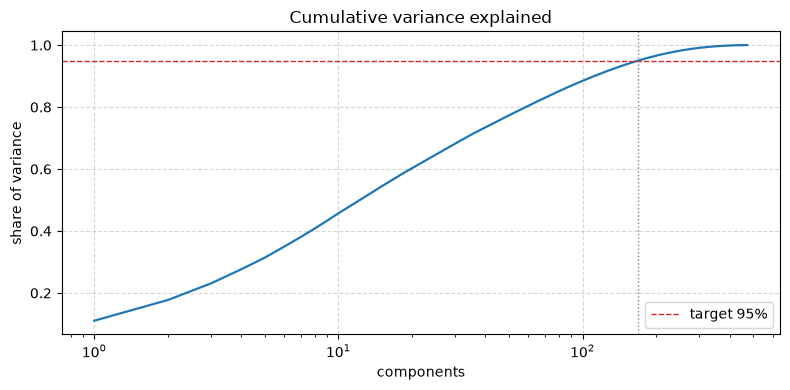

In [31]:
PCA_VARIANCE_TARGET = 0.95

# scikit-learn: passing a float (0, 1) to n_components picks the smallest number of
# components whose cumulative explained variance reaches that share.
variance_probe = PCA(n_components=PCA_VARIANCE_TARGET, random_state=42).fit(ticket_embeddings)
PCA_COMPONENTS = variance_probe.n_components_
cum_variance = PCA(random_state=42).fit(ticket_embeddings).explained_variance_ratio_.cumsum()

print(f"PCA_COMPONENTS = {PCA_COMPONENTS}  "
      f"(smallest count reaching {PCA_VARIANCE_TARGET:.0%} of the variance)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum_variance) + 1), cum_variance, lw=1.6)
ax.axhline(PCA_VARIANCE_TARGET, ls="--", lw=1, color="tab:red", label=f"target {PCA_VARIANCE_TARGET:.0%}")
ax.axvline(PCA_COMPONENTS, ls=":", lw=1, color="gray")
ax.set(title="Cumulative variance explained", xlabel="components", ylabel="share of variance")
ax.set_xscale("log")
ax.legend()
ax.grid(linestyle="--", alpha=.5)
plt.tight_layout()
plt.show()


Fit the final PCA space and compare it with `ticket_embeddings`

ticket_embeddings     (473, 1024)
pca_ticket_embeddings (473, 169)  variance kept 95.0%  top component 11.0%

pairwise cosine: mean 0.883, min 0.779  (ticket_embeddings, 1024-d)
                 mean -0.002, min -0.394  (pca_ticket_embeddings, 169-d)
The distribution now spans negative values: unrelated tickets are finally far apart.


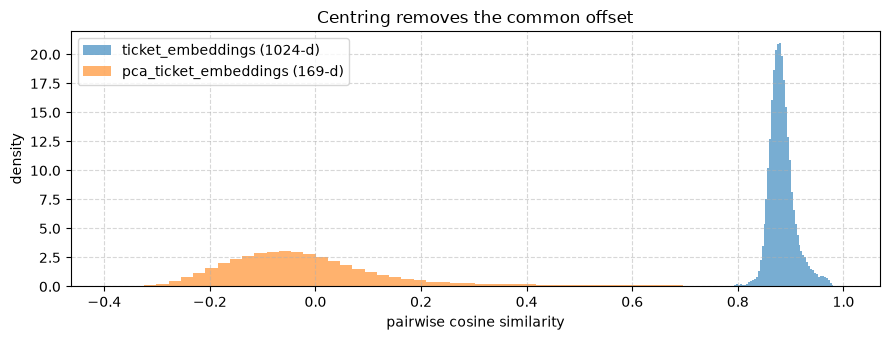

In [32]:
# Final PCA space for KMeans / agglomerative clustering. Unit-normalised, so cosine
# similarity is still a dot product and spherical KMeans still applies.
pca_ticket_embeddings, pca_model = pca_reduce(ticket_embeddings, PCA_COMPONENTS)

print(f"ticket_embeddings     {ticket_embeddings.shape}")
print(f"pca_ticket_embeddings {pca_ticket_embeddings.shape}  "
      f"variance kept {pca_model.explained_variance_ratio_.sum():.1%}  "
      f"top component {pca_model.explained_variance_ratio_[0]:.1%}")

# Anisotropy before/after: the common offset should be gone once centred.
before = (ticket_embeddings @ ticket_embeddings.T)[~np.eye(NUMBER_DOCS, dtype=bool)]
after = (pca_ticket_embeddings @ pca_ticket_embeddings.T)[~np.eye(NUMBER_DOCS, dtype=bool)]
print(f"\npairwise cosine: mean {before.mean():.3f}, min {before.min():.3f}  (ticket_embeddings, 1024-d)")
print(f"                 mean {after.mean():.3f}, min {after.min():.3f}  (pca_ticket_embeddings, {PCA_COMPONENTS}-d)")
print("The distribution now spans negative values: unrelated tickets are finally far apart.")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(before, bins=60, alpha=.6, label="ticket_embeddings (1024-d)", density=True)
ax.hist(after, bins=60, alpha=.6, label=f"pca_ticket_embeddings ({PCA_COMPONENTS}-d)", density=True)
ax.set(xlabel="pairwise cosine similarity", ylabel="density", title="Centring removes the common offset")
ax.legend(); ax.grid(linestyle="--", alpha=.5)

plt.tight_layout()
plt.savefig("images/pairwise_cosine_pca_before_after.png", dpi=300)
plt.show()


## Clustering

| Model | Family | Needs `k`? | Noise? | Why it is here |
|---|---|---|---|---|
| **KMeans** | partition | yes | no | fast, stable baseline; the usual choice for embedding clustering |
| **Agglomerative (Ward)** | hierarchical | yes | no | exposes the product -> intent hierarchy the 2-D preview suggested |
| **HDBSCAN** | density | no | yes | finds tight groups of any count and leaves ambiguous tickets unassigned |

Primary metric: **cosine silhouette** (higher is better, range -1..1). Secondary: Davies-Bouldin
(lower is better) and Calinski-Harabasz (higher is better). HDBSCAN metrics are computed on the
assigned points only, so its noise share is reported alongside and must be read together with them.

Auxiliary methods

In [33]:
CLUSTER_SEED = 42
TOP_TERMS = 6


def evaluate_clustering(labels, vectors=None):
    """Internal metrics on assigned points; HDBSCAN noise (label -1) is excluded and counted."""
    vectors = pca_ticket_embeddings if vectors is None else vectors
    mask = labels >= 0
    n_clusters = len(set(labels[mask]))
    row = {"clusters": n_clusters, "noise share": float((~mask).mean())}
    if n_clusters > 1:
        row["silhouette"] = silhouette_score(vectors[mask], labels[mask], metric="cosine")
        row["davies_bouldin"] = davies_bouldin_score(vectors[mask], labels[mask])
        row["calinski_harabasz"] = calinski_harabasz_score(vectors[mask], labels[mask])
    return row


def cluster_top_terms(labels, n_terms=TOP_TERMS):
    """Most characteristic TF-IDF terms per cluster, reusing signal_mat from the cleaning section."""
    out = {}
    for c in sorted(set(labels)):
        members = np.where(labels == c)[0]
        weight = np.asarray(signal_mat[members].mean(axis=0)).ravel()
        out[c] = ", ".join(signal_terms[i] for i in np.argsort(-weight)[:n_terms])
    return out


def describe_clusters(labels, n_terms=TOP_TERMS):
    """One row per cluster: size, share and top terms. Noise (-1) listed last."""
    terms = cluster_top_terms(labels, n_terms)
    sizes = pd.Series(labels).value_counts()
    table = pd.DataFrame({"size": sizes, "share": sizes / len(labels),
                          "top terms": pd.Series(terms)}).sort_values("size", ascending=False)
    if -1 in table.index:
        table = pd.concat([table.drop(-1), table.loc[[-1]].rename(index={-1: "noise"})])
    return table

### KMeans and Agglomerative: choose `k`

Sweep `k` and keep the value that maximises cosine silhouette for each model separately.
The 2-D UMAP preview hinted at 15-20 tight groups, so the sweep deliberately goes past that.

KMEANS_K = 19  (silhouette 0.337)
AGGLO_K  = 26  (silhouette 0.359)


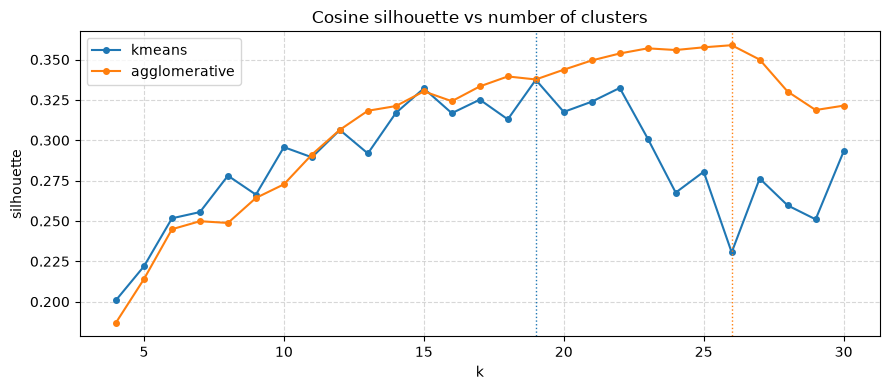

In [34]:
K_RANGE = range(4, 31)

k_sweep = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=CLUSTER_SEED).fit(pca_ticket_embeddings)
    ag = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(pca_ticket_embeddings)
    k_sweep.append({"k": k,
                    "kmeans": silhouette_score(pca_ticket_embeddings, km.labels_, metric="cosine"),
                    "agglomerative": silhouette_score(pca_ticket_embeddings, ag.labels_, metric="cosine")})
k_sweep = pd.DataFrame(k_sweep).set_index("k")

KMEANS_K = int(k_sweep["kmeans"].idxmax())
AGGLO_K = int(k_sweep["agglomerative"].idxmax())
print(f"KMEANS_K = {KMEANS_K}  (silhouette {k_sweep['kmeans'].max():.3f})")
print(f"AGGLO_K  = {AGGLO_K}  (silhouette {k_sweep['agglomerative'].max():.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
for name, colour in [("kmeans", "tab:blue"), ("agglomerative", "tab:orange")]:
    ax.plot(k_sweep.index, k_sweep[name], marker="o", ms=4, label=name, color=colour)
ax.axvline(KMEANS_K, ls=":", lw=1, color="tab:blue")
ax.axvline(AGGLO_K, ls=":", lw=1, color="tab:orange")
ax.set(title="Cosine silhouette vs number of clusters", xlabel="k", ylabel="silhouette")
ax.legend(); ax.grid(linestyle="--", alpha=.5)

plt.tight_layout()
plt.savefig("images/silhouette_k_sweep.png", dpi=300)
plt.show()

### HDBSCAN: choose `min_cluster_size`

HDBSCAN has no `k`; the lever is the smallest group it may call a cluster. Smaller values find
more, tighter groups but also label more tickets as noise. The sweep keeps the best silhouette
among settings that leave at most `NOISE_MAX` of the tickets unassigned.

In [35]:
HDBSCAN_MIN_CLUSTER_SIZES = np.arange(3, 15)
HDBSCAN_MIN_SAMPLES = [None]  # None -> defaults to min_cluster_size
NOISE_MAX = 0.30

# sklearn's HDBSCAN needs float64 for the cosine metric.
hdbscan_input = pca_ticket_embeddings.astype(np.float64)

hdbscan_sweep = []
for mcs in HDBSCAN_MIN_CLUSTER_SIZES:
    for ms in HDBSCAN_MIN_SAMPLES:
        model = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="cosine", copy=False).fit(hdbscan_input)
        hdbscan_sweep.append({"min_cluster_size": mcs, "min_samples": ms, **evaluate_clustering(model.labels_)})
hdbscan_sweep = pd.DataFrame(hdbscan_sweep)
hdbscan_sweep

,min_cluster_size,min_samples,clusters,noise share,silhouette,davies_bouldin,calinski_harabasz
0,3,None,37,0.221987,0.415316,1.335578,17.557669
1,4,None,23,0.253700,0.434259,1.395723,23.787487
2,5,None,18,0.281184,0.449645,1.415851,28.547833
3,6,None,13,0.327696,0.462885,1.426581,36.484220
4,7,None,13,0.342495,0.466580,1.403430,35.851489
5,8,None,9,0.266385,0.403685,1.508307,35.024321
6,9,None,9,0.287526,0.411522,1.484874,34.892937
7,10,None,8,0.283298,0.393514,1.616329,37.229673
8,11,None,8,0.304440,0.403720,1.592556,37.300285
9,12,None,8,0.319239,0.408615,1.575795,37.224998


Pick up the model with a low number of cluster but low noise share and high silhouette score.

In [36]:
HDBSCAN_MIN_CLUSTER_SIZE = 7
HDBSCAN_MIN_SAMPLES_BEST = None
eligible = hdbscan_sweep[hdbscan_sweep["min_cluster_size"] == HDBSCAN_MIN_CLUSTER_SIZE]

print(f"\nHDBSCAN_MIN_CLUSTER_SIZE = {HDBSCAN_MIN_CLUSTER_SIZE}, min_samples = {HDBSCAN_MIN_SAMPLES_BEST}  "
      f"({int(eligible['clusters'].iloc[0])} clusters, noise {eligible['noise share'].iloc[0]:.1%}, silhouette {eligible['silhouette'].iloc[0]:.3f})")


HDBSCAN_MIN_CLUSTER_SIZE = 7, min_samples = None  (13 clusters, noise 34.2%, silhouette 0.467)


### Fit the final models and compare

In [37]:
kmeans_model = KMeans(n_clusters=KMEANS_K, n_init=10, random_state=CLUSTER_SEED).fit(pca_ticket_embeddings)
agglo_model = AgglomerativeClustering(n_clusters=AGGLO_K, linkage="ward").fit(pca_ticket_embeddings)
hdbscan_model = HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, min_samples=HDBSCAN_MIN_SAMPLES_BEST,
                        metric="cosine", copy=False).fit(hdbscan_input)

cluster_labels = {
    "kmeans": kmeans_model.labels_,
    "agglomerative": agglo_model.labels_,
    "hdbscan": hdbscan_model.labels_,
}
for name, labels in cluster_labels.items():
    cleaned_tickets_df[f"cluster_{name}"] = labels

comparison = pd.DataFrame({name: evaluate_clustering(labels) for name, labels in cluster_labels.items()}).T
comparison

,clusters,noise share,silhouette,davies_bouldin,calinski_harabasz
kmeans,19.0,0.000000,0.337463,1.937219,24.398770
agglomerative,26.0,0.000000,0.358910,1.877429,20.949356
hdbscan,13.0,0.342495,0.466580,1.403430,35.851489


Cluster sizes side by side

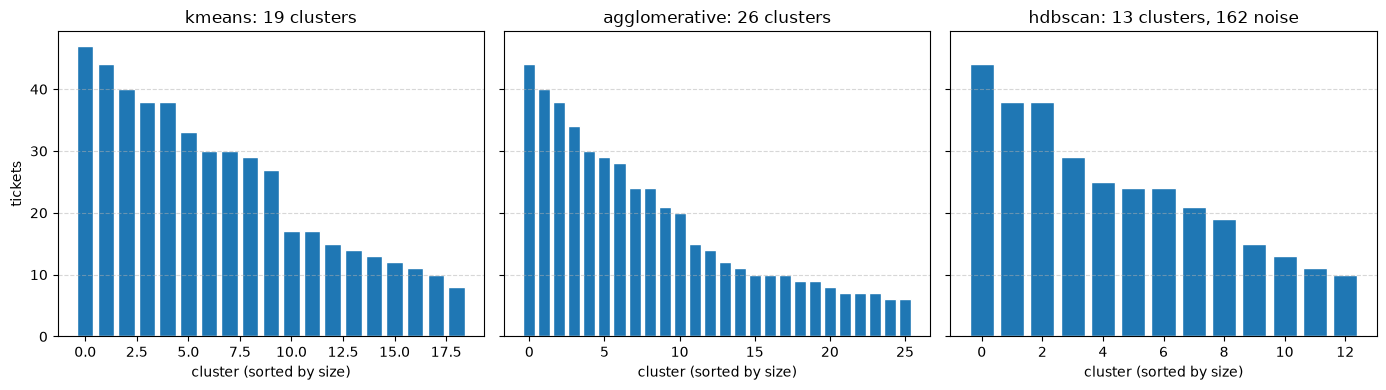

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (name, labels) in zip(axes, cluster_labels.items()):
    sizes = pd.Series(labels[labels >= 0]).value_counts().sort_values(ascending=False)
    ax.bar(np.arange(len(sizes)), sizes.to_numpy(), color="tab:blue", edgecolor="white")
    noise = int((labels < 0).sum())
    ax.set_title(f"{name}: {len(sizes)} clusters" + (f", {noise} noise" if noise else ""))
    ax.set_xlabel("cluster (sorted by size)")
    ax.grid(axis="y", linestyle="--", alpha=.5)
axes[0].set_ylabel("tickets")

plt.tight_layout()
plt.savefig("images/cluster_sizes.png", dpi=300)
plt.show()

What is inside each cluster? Top TF-IDF terms per cluster, for each model.

In [39]:
describe_clusters(cluster_labels["kmeans"])

,size,share,top terms
10,47,0.099366,"ti, consultoria, consultoria ti, servidor, serviço consultoria, serviços"
1,44,0.093023,"roteador, cisco, isr4331, roteador cisco, cisco isr4331, rede"
3,40,0.084567,"jira, jira software, software, 20, software 20, projetos"
5,38,0.080338,"dell, xps, dell xps, xps 13, 13, 9310"
2,38,0.080338,"aws, serviço, interrupção, gerenciamento aws, serviço gerenciamento, urgente"
14,33,0.069767,"pro, surface, surface pro, microsoft surface, microsoft, tela"
9,30,0.063425,"aws, custos, otimização, gerenciamento aws, gerenciamento, otimização custos"
6,30,0.063425,"hp, hp deskjet, 3755, deskjet, deskjet 3755, impressora"
8,29,0.061311,"canon, impressora, pixma, mg3620, canon pixma, pixma mg3620"
4,27,0.057082,"macbook, macbook air, air, m1, air m1, compra"


In [40]:
describe_clusters(cluster_labels["agglomerative"])

,size,share,top terms
11,44,0.093023,"roteador, cisco, isr4331, roteador cisco, cisco isr4331, rede"
1,40,0.084567,"jira, jira software, software, 20, software 20, projetos"
6,38,0.080338,"dell, xps, dell xps, xps 13, 13, 9310"
13,34,0.071882,"aws, serviço, interrupção, gerenciamento aws, serviço gerenciamento, urgente"
8,30,0.063425,"aws, custos, gerenciamento aws, otimização, gerenciamento, serviço"
5,29,0.061311,"ti, consultoria, consultoria ti, servidores, serviços, serviço consultoria"
3,28,0.059197,"hp, deskjet, hp deskjet, deskjet 3755, 3755, impressora"
19,24,0.050740,"canon, mg3620, canon pixma, pixma, pixma mg3620, impressora"
0,24,0.050740,"macbook, macbook air, air, m1, air m1, compra"
18,21,0.044397,"servidor, ti, consultoria, consultoria ti, serviço consultoria, sistema"


In [41]:
describe_clusters(cluster_labels["hdbscan"])

,size,share,top terms
0,44,0.093023,"roteador, cisco, isr4331, roteador cisco, cisco isr4331, rede"
4,38,0.080338,"dell, xps, dell xps, xps 13, 13, 9310"
5,38,0.080338,"jira, jira software, software, 20, software 20, projetos"
10,29,0.061311,"ti, consultoria, consultoria ti, servidores, servidor, serviços"
1,25,0.052854,"hp, hp deskjet, deskjet 3755, deskjet, 3755, fio"
12,24,0.050740,"aws, serviço, serviço gerenciamento, gerenciamento aws, interrupção, gerenciamento"
2,24,0.050740,"canon, mg3620, canon pixma, pixma, pixma mg3620, impressora"
6,21,0.044397,"macbook air, macbook, air, m1, air m1, compra"
11,19,0.040169,"aws, custos, otimização, gerenciamento aws, otimização custos, gerenciamento"
3,15,0.031712,"zoom, 11, reuniões, versão, vídeo, chamadas"


## Cluster descriptions with a local LLM

A local LLM reads a handful of representative tickets per cluster and writes a one-line description plus keywords. Everything runs on this machine through [Ollama](https://ollama.com).

### Model options

Two constraints drive the choice: the prompt budget and the language.

**Prompt budget.** Tickets are short - median 127 tokens, p90 259 (embedding section). Ten representative tickets plus instructions is ~2-3k tokens, and even a whole 45-ticket cluster is ~7k. Every Llama 3.x model has a 128k window, so context is not the limit; the limit is the 8 GB of VRAM on this GPU, which decides which model runs at a usable speed.

| Model | Params | VRAM (Q4) | PT-BR | Notes |
|---|---|---|---|---|
| **`llama3.1:8b`** | 8B | ~5 GB | official | Portuguese is one of the 8 officially supported languages; fits the GPU |
| `llama3.2:3b` | 3B | ~2 GB | official | Same language list, noticeably weaker phrasing and keyword precision |
| `llama3.2:1b` | 1B | ~1 GB | official | Too weak for summarisation |
| `llama3.3:70b` | 70B | ~43 GB | official | Best quality, does not fit in 8 GB |
| PT-BR fine-tunes (Bode, Tucano) | 7-13B | ~5-8 GB | native | Based on Llama 2 / smaller bases; weaker instruction following than Llama 3.1 |

### Chosen model

`llama3.1:8b`: the largest officially Portuguese-capable Llama that fits the GPU, and instruction
tuned - so it follows a JSON schema, which lets the output be parsed instead of scraped.

Auxiliary methods

In [42]:
OLLAMA_URL = "http://localhost:11434"
LLM_MODEL = "llama3.1:8b"
LLM_TICKETS_PER_CLUSTER = 10   # nearest to the centroid
LLM_MAX_CHARS_PER_TICKET = 800  # ~p90 ticket length; bounds the prompt
LLM_CACHE_DIR = Path("dataset/cluster_descriptions")

LLM_SCHEMA = {
    "type": "object",
    "properties": {
        "description": {"type": "string"},
        "keywords": {"type": "array", "items": {"type": "string"}, "minItems": 4, "maxItems": 8},
    },
    "required": ["description", "keywords"],
}

LLM_SYSTEM = (
    "Você é um analista sênior de suporte técnico. Responda sempre em português do Brasil, "
    "de forma objetiva, sem saudações e sem repetir o texto dos tickets."
)

LLM_PROMPT = """Os tickets abaixo foram agrupados automaticamente por similaridade. Todos pertencem ao mesmo grupo.

Termos mais frequentes do grupo: {terms}

Tickets representativos:
{tickets}

Com base nesses tickets, produza:
- "description": uma ou duas frases descrevendo o que os clientes deste grupo precisam (produto, problema e intenção, por exemplo: falha técnica, cobrança, cancelamento, dúvida).
- "keywords": de 4 a 8 palavras-chave curtas, em minúsculas, específicas deste grupo, sem genéricos como "problema" ou "suporte".

Responda apenas com o JSON."""


def ollama_chat(prompt, system=LLM_SYSTEM, schema=LLM_SCHEMA, model=LLM_MODEL, num_ctx=8192):
    """One structured call to a local Ollama model; returns the parsed JSON object."""
    body = json.dumps({
        "model": model,
        "messages": [{"role": "system", "content": system}, {"role": "user", "content": prompt}],
        "format": schema,
        "stream": False,
        "options": {"temperature": 0, "num_ctx": num_ctx},
    }).encode("utf-8")
    request = urllib.request.Request(f"{OLLAMA_URL}/api/chat", data=body,
                                     headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(request, timeout=600) as response:
        reply = json.load(response)
    return json.loads(reply["message"]["content"])


def representative_tickets(labels, cluster, n=LLM_TICKETS_PER_CLUSTER):
    """Members closest to the cluster centroid in the PCA space (cosine, unit vectors)."""
    members = np.where(labels == cluster)[0]
    centroid = normalize(pca_ticket_embeddings[members].mean(axis=0, keepdims=True))[0]
    order = members[np.argsort(-(pca_ticket_embeddings[members] @ centroid))]
    return cleaned_tickets_df.iloc[order[:n]]


def describe_cluster_llm(labels, cluster, cache_dir=LLM_CACHE_DIR):
    """Description + keywords for one cluster, cached on disk by prompt hash."""
    sample = representative_tickets(labels, cluster)
    tickets = "\n\n".join(
        f"[{tid}] {text[:LLM_MAX_CHARS_PER_TICKET]}"
        for tid, text in sample["cleaned_full_text"].items())
    prompt = LLM_PROMPT.format(terms=cluster_top_terms(labels)[cluster], tickets=tickets)

    cache_dir.mkdir(parents=True, exist_ok=True)
    digest = hashlib.sha1((LLM_MODEL + LLM_SYSTEM + prompt).encode("utf-8")).hexdigest()[:12]
    cache_path = cache_dir / f"{digest}.json"
    if cache_path.exists():
        return json.loads(cache_path.read_text(encoding="utf-8"))

    result = ollama_chat(prompt)
    result["keywords"] = [k.strip().lower() for k in result["keywords"] if k.strip()]
    cache_path.write_text(json.dumps(result, ensure_ascii=False, indent=1), encoding="utf-8")
    return result

### Agglomerative cluster descriptions

In [43]:
LLM_LABEL_SOURCE = "agglomerative"
llm_labels = cluster_labels[LLM_LABEL_SOURCE]

assert urllib.request.urlopen(f"{OLLAMA_URL}/api/version", timeout=5).status == 200, "Ollama is not running"

started = time.perf_counter()
rows = []
for cluster in sorted(c for c in set(llm_labels) if c >= 0):
    result = describe_cluster_llm(llm_labels, cluster)
    rows.append({"cluster": cluster, "size": int((llm_labels == cluster).sum()),
                 "keywords": ", ".join(result["keywords"]), "description": result["description"]})
    print(f"cluster {cluster:>2} ({rows[-1]['size']:>3} tickets)  {rows[-1]['keywords']}")

cluster_descriptions = pd.DataFrame(rows).set_index("cluster").sort_values("size", ascending=False)
print(f"\n{len(cluster_descriptions)} clusters described by {LLM_MODEL} in {time.perf_counter() - started:.0f}s")

cluster_descriptions.to_csv(f"dataset/cluster_descriptions_{LLM_LABEL_SOURCE}.csv", encoding="utf-8")
pd.set_option("display.max_colwidth", 160)
cluster_descriptions

cluster  0 ( 24 tickets)  macbook air m1, bateria, entrega, devolução, compra, suporte técnico
cluster  1 ( 40 tickets)  jira software, atualização, gerenciamento de projetos, recursos aprimorados, problemas técnicos
cluster  2 ( 10 tickets)  cobrança incorreta, cobrança duplicada, google chrome, mysql, microsoft office 365, intellij idea, cobrança inesperada
cluster  3 ( 28 tickets)  hp deskjet 3755, impressora sem fio, conectividade wi-fi, configuração sem fio, problema de impressão, hp deskjet, deskjet 3755
cluster  4 ( 11 tickets)  visual studio code, depuração, extensões, integração, suporte técnico, desenvolvimento, programação
cluster  5 ( 29 tickets)  consultoria ti, administração de servidores, otimização de desempenho, serviços de consultoria, soluções de ti, gestão de servidores, desenvolvimento de software
cluster  6 ( 38 tickets)  dell xps 13 9310, problemas técnicos, suporte técnico, dell xps 13, 9310, super aquecimento, tela azul
cluster  7 (  9 tickets)  atraso entrega,

,size,keywords,description
cluster,,,
11,44,"roteador cisco, isr4331, conectividade, estabilidade, rede, desconexões, problemas de rede",Resolução de problemas de conectividade e estabilidade do Roteador Cisco ISR4331
1,40,"jira software, atualização, gerenciamento de projetos, recursos aprimorados, problemas técnicos",Atualização do Jira Software 8.20 para acessar recursos aprimorados e resolver problemas de gerenciamento de projetos
6,38,"dell xps 13 9310, problemas técnicos, suporte técnico, dell xps 13, 9310, super aquecimento, tela azul","Problemas técnicos com Dell XPS 13 9310, incluindo superaquecimento, tela azul, inicialização, bateria e touchpad"
13,34,"aws, serviço de gerenciamento, interrupção, gerenciamento aws, serviço gerenciamento","Problema de interrupção do Serviço de Gerenciamento da AWS, necessitando de assistência urgente para restaurar a funcionalidade e evitar impactos nas operaç..."
8,30,"aws, custos, gerenciamento aws, otimização, serviço de gerenciamento, infraestrutura em nuvem, eficiência de desempenho",Otimização de custos e eficiência da infraestrutura AWS
5,29,"consultoria ti, administração de servidores, otimização de desempenho, serviços de consultoria, soluções de ti, gestão de servidores, desenvolvimento de sof...","Administração de servidores, otimização de desempenho e consultoria em TI"
3,28,"hp deskjet 3755, impressora sem fio, conectividade wi-fi, configuração sem fio, problema de impressão, hp deskjet, deskjet 3755",Problemas de conectividade com impressora HP DeskJet 3755
19,24,"canon pixma mg3620, conexão sem fio, impressora, canon pixma, conectividade, wifi, configuração",Falha de conexão sem fio na impressora Canon PIXMA MG3620
0,24,"macbook air m1, bateria, entrega, devolução, compra, suporte técnico","Compras de MacBook Air M1 com problemas de bateria, entrega e devolução"


### KMeans clusters description

In [44]:
LLM_LABEL_SOURCE = "kmeans"
llm_labels = cluster_labels[LLM_LABEL_SOURCE]

assert urllib.request.urlopen(f"{OLLAMA_URL}/api/version", timeout=5).status == 200, "Ollama is not running"

started = time.perf_counter()
rows = []
for cluster in sorted(c for c in set(llm_labels) if c >= 0):
    result = describe_cluster_llm(llm_labels, cluster)
    rows.append({"cluster": cluster, "size": int((llm_labels == cluster).sum()),
                 "keywords": ", ".join(result["keywords"]), "description": result["description"]})
    print(f"cluster {cluster:>2} ({rows[-1]['size']:>3} tickets)  {rows[-1]['keywords']}")

cluster_descriptions = pd.DataFrame(rows).set_index("cluster").sort_values("size", ascending=False)
print(f"\n{len(cluster_descriptions)} clusters described by {LLM_MODEL} in {time.perf_counter() - started:.0f}s")

cluster_descriptions.to_csv(f"dataset/cluster_descriptions_{LLM_LABEL_SOURCE}.csv", encoding="utf-8")
pd.set_option("display.max_colwidth", 160)
cluster_descriptions

cluster  0 ( 10 tickets)  slack, interrupção serviço, melhorar eficiência, software fica, implementação, conexão, instalação
cluster  1 ( 44 tickets)  roteador cisco, isr4331, conectividade, estabilidade, rede, desconexões, problemas de rede
cluster  2 ( 38 tickets)  aws, serviço, interrupção, gerenciamento aws, serviço gerenciamento, urgente, inatividade
cluster  3 ( 40 tickets)  jira software, atualização, gerenciamento de projetos, recursos aprimorados, problemas técnicos
cluster  4 ( 27 tickets)  macbook air m1, compra, bateria, problema, entrega, disponibilidade, suporte
cluster  5 ( 38 tickets)  dell xps 13 9310, problemas técnicos, suporte técnico, dell xps 13, 9310, super aquecimento, tela azul
cluster  6 ( 30 tickets)  hp deskjet 3755, impressora sem fio, conectividade wi-fi, configuração sem fio, problema de conexão, impressora hp, deskjet 3755
cluster  7 ( 17 tickets)  google workspace, cobrança incorreta, faturamento, google workspace business, discrepância de cobrança
clus

,size,keywords,description
cluster,,,
10,47,"consultoria ti, servidor, administração de servidores, soluções de ti, otimização de desempenho, gestão de servidores, consultoria de ti",Otimização de administração de servidores e soluções de TI
1,44,"roteador cisco, isr4331, conectividade, estabilidade, rede, desconexões, problemas de rede",Resolução de problemas de conectividade e estabilidade do Roteador Cisco ISR4331
3,40,"jira software, atualização, gerenciamento de projetos, recursos aprimorados, problemas técnicos",Atualização do Jira Software 8.20 para acessar recursos aprimorados e resolver problemas de gerenciamento de projetos
5,38,"dell xps 13 9310, problemas técnicos, suporte técnico, dell xps 13, 9310, super aquecimento, tela azul","Problemas técnicos com Dell XPS 13 9310, incluindo superaquecimento, tela azul, inicialização, bateria e touchpad"
2,38,"aws, serviço, interrupção, gerenciamento aws, serviço gerenciamento, urgente, inatividade","Problema de inatividade do Serviço de Gerenciamento da AWS, interrupção de serviço e tempo de inatividade"
14,33,"surface pro, tela sensível ao toque, não responsiva, microsoft surface, problema de tela, suporte técnico, reparo",Problemas de tela sensível ao toque no Microsoft Surface Pro
9,30,"aws, custos, otimização, gerenciamento aws, gerenciamento, otimização custos",Otimização de custos e eficiência da infraestrutura AWS
6,30,"hp deskjet 3755, impressora sem fio, conectividade wi-fi, configuração sem fio, problema de conexão, impressora hp, deskjet 3755",Problemas de conectividade Wi-Fi com a impressora HP DeskJet 3755
8,29,"canon pixma mg3620, conexão sem fio, impressora, canon pixma, pixma mg3620, conectividade, impressora canon",Falha de conexão sem fio na impressora Canon PIXMA MG3620


### HDBSCAN clusters description

In [45]:
LLM_LABEL_SOURCE = "hdbscan"
llm_labels = cluster_labels[LLM_LABEL_SOURCE]

assert urllib.request.urlopen(f"{OLLAMA_URL}/api/version", timeout=5).status == 200, "Ollama is not running"

started = time.perf_counter()
rows = []
for cluster in sorted(c for c in set(llm_labels) if c >= 0):
    result = describe_cluster_llm(llm_labels, cluster)
    rows.append({"cluster": cluster, "size": int((llm_labels == cluster).sum()),
                 "keywords": ", ".join(result["keywords"]), "description": result["description"]})
    print(f"cluster {cluster:>2} ({rows[-1]['size']:>3} tickets)  {rows[-1]['keywords']}")

cluster_descriptions = pd.DataFrame(rows).set_index("cluster").sort_values("size", ascending=False)
print(f"\n{len(cluster_descriptions)} clusters described by {LLM_MODEL} in {time.perf_counter() - started:.0f}s")

cluster_descriptions.to_csv(f"dataset/cluster_descriptions_{LLM_LABEL_SOURCE}.csv", encoding="utf-8")
pd.set_option("display.max_colwidth", 160)
cluster_descriptions

cluster  0 ( 44 tickets)  roteador cisco, isr4331, conectividade, estabilidade, rede, desconexões, problemas de rede
cluster  1 ( 25 tickets)  hp deskjet 3755, conectividade sem fio, impressora hp, configuração sem fio, problema de conexão, impressora não conecta, configuração de rede
cluster  2 ( 24 tickets)  canon pixma mg3620, conexão sem fio, impressora, canon pixma, conectividade, wifi, configuração
cluster  3 ( 15 tickets)  zoom, conectividade, áudio, vídeo, chamadas, reuniões, versão 5.11.0
cluster  4 ( 38 tickets)  dell xps 13 9310, problemas técnicos, suporte técnico, dell xps 13, 9310, super aquecimento, tela azul
cluster  5 ( 38 tickets)  jira software, atualização, gerenciamento de projetos, tickets, fluxo de trabalho
cluster  6 ( 21 tickets)  macbook air m1, compra, disponibilidade, bateria, problema, entrega, devolução
cluster  7 ( 13 tickets)  surface pro, tela sensível, touchscreen, microsoft surface, problema de tela, mal funcionamento, não responde
cluster  8 ( 10 tic

,size,keywords,description
cluster,,,
0,44,"roteador cisco, isr4331, conectividade, estabilidade, rede, desconexões, problemas de rede",Resolução de problemas de conectividade e estabilidade do Roteador Cisco ISR4331
4,38,"dell xps 13 9310, problemas técnicos, suporte técnico, dell xps 13, 9310, super aquecimento, tela azul","Problemas técnicos com Dell XPS 13 9310, incluindo superaquecimento, tela azul, inicialização, bateria e touchpad"
5,38,"jira software, atualização, gerenciamento de projetos, tickets, fluxo de trabalho",Atualização do Jira Software 8.20 para resolver problemas de gerenciamento de projetos
10,29,"consultoria ti, administração de servidores, otimização de soluções, servidores, consultoria, serviços de consultoria, administração de servidores, otimizaç...",Consultoria de TI para administração de servidores e otimização de soluções
1,25,"hp deskjet 3755, conectividade sem fio, impressora hp, configuração sem fio, problema de conexão, impressora não conecta, configuração de rede",Problemas de conectividade com impressora HP DeskJet 3755
12,24,"aws, serviço, gerenciamento, interrupção, inatividade, suporte, urgente","Interrupções no Serviço de Gerenciamento da AWS, necessidade de assistência urgente para restaurar operações"
2,24,"canon pixma mg3620, conexão sem fio, impressora, canon pixma, conectividade, wifi, configuração",Falha de conexão sem fio na impressora Canon PIXMA MG3620
6,21,"macbook air m1, compra, disponibilidade, bateria, problema, entrega, devolução",Compras e problemas com MacBook Air M1
11,19,"aws, custos, otimização, gerenciamento aws, otimização custos, gerenciamento",Otimização de custos e eficiência da infraestrutura AWS


## Ticket groups for classification

For a first classifier, several clusters are merged into meaningful categories based on the keywords and descriptions from the HDBSCAN clusters. The noise bucket is then revisited with label spreading, so that `Other` keeps only the tickets that are genuinely far from every group.

In [46]:
# HDBSCAN cluster id -> business category, read off the top terms / LLM descriptions above.
TICKET_GROUPS = {
    "Rede": [0],
    "Computador": [4, 6],
    "Tablet": [7],
    "Jira": [5],
    "AWS": [12, 11, 9],
    "Impressora": [1, 2],
    "Servidor": [10],
    "Licença de Software": [8],
    "Video Conferência":[3],
    "Other": [-1],
}

Map every ticket to its group through its HDBSCAN cluster. This is the *initial* assignment, kept as `group_hdbscan`.

In [47]:
hdbscan_labels = pd.Series(cluster_labels["hdbscan"], index=cleaned_tickets_df.index)

# Every HDBSCAN cluster (and the noise bucket) must be claimed by exactly one group.
grouped_clusters = [c for clusters in TICKET_GROUPS.values() for c in clusters]
assert sorted(grouped_clusters) == sorted(set(hdbscan_labels)), \
    "TICKET_GROUPS does not exactly cover the HDBSCAN clusters - update the mapping above"
assert len(grouped_clusters) == len(set(grouped_clusters)), "a cluster was assigned to more than one group"

cluster_to_group = {c: group for group, clusters in TICKET_GROUPS.items() for c in clusters}
cleaned_tickets_df["group_hdbscan"] = hdbscan_labels.map(cluster_to_group)
assert cleaned_tickets_df["group_hdbscan"].notna().all()

print(cleaned_tickets_df["group_hdbscan"].value_counts().to_string())

group_hdbscan
Other                  162
Computador              59
AWS                     54
Impressora              49
Rede                    44
Jira                    38
Servidor                29
Video Conferência       15
Tablet                  13
Licença de Software     10


### Label spreading: reclaiming the noise group

HDBSCAN leaves 133 tickets (28%) without group. Some are genuinely off-topic, but many are ordinary tickets that fell just outside a cluster's density, for instance an Epson printer among the HP and Canon ones.

In Label spreading, the grouped tickets are labelled seeds, the noise tickets (`Other` group) are unlabelled. Every ticket ends with a distribution over the eight groups. `alpha` lets a
seed's own label be overridden by its neighbourhood, which doubles as a consistency check on the groups.

Diffusion hands *every* ticket a winner, so two gates decide which noise tickets are actually reclaimed:

- **Decisive vote** - the winning group holds at least `LS_MIN_PROBABILITY` of the ticket's distribution.
- **Anchored** - the ticket's cosine to its nearest existing member of the winning group is at least
  `LS_MIN_ANCHOR`. This is the gate that matters. A ticket surrounded only by other noise can still inherit
  a decisive label through the graph (an IntelliJ ticket "wins" Jira via other developer-tool tickets)
  without being close to any real member. In the centred space unrelated tickets sit near cosine 0, so
  0.45 reads as "clearly related" - well below what cluster members share with each other (median 0.79),
  but far from chance.

A ticket failing either gate stays in `Other`.

seeds whose neighbourhood outvoted their own group: 0 of 311
noise tickets: 162  ->  reclaimed 60, kept as Other 102
  kept: decisive but not anchored 26, anchored but not decisive 12, neither 64

for reference, cosine to the nearest same-group member among seeds: median 0.79, 5th percentile 0.62


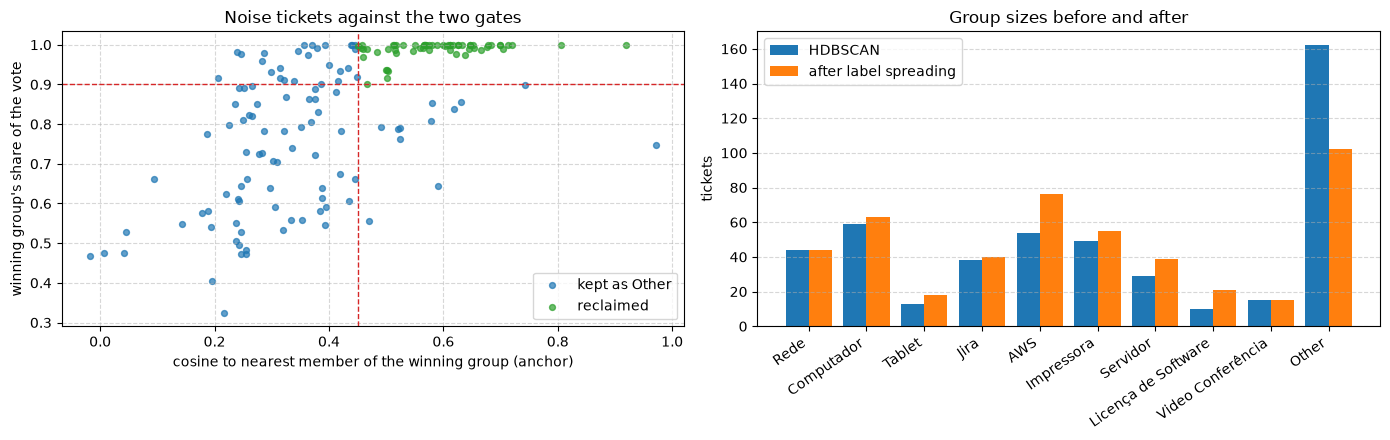

In [48]:
LS_K = 10                  # neighbours per ticket in the graph (same K as the PCA neighbour check)
LS_ALPHA = 0.2             # clamping: a seed keeps 80% of its own label at every step
LS_MIN_PROBABILITY = 0.90  # decisive-vote gate
LS_MIN_ANCHOR = 0.45       # anchored gate: cosine to the nearest member of the winning group

GROUPS = [g for g in TICKET_GROUPS if g != "Other"]
group_hdbscan = cleaned_tickets_df["group_hdbscan"].to_numpy()
seed_labels = np.array([GROUPS.index(g) if g in GROUPS else -1 for g in group_hdbscan])
is_seed = seed_labels >= 0

spreader = LabelSpreading(kernel="knn", n_neighbors=LS_K, alpha=LS_ALPHA, max_iter=1000)
spreader.fit(pca_ticket_embeddings, seed_labels)
ls_winner = np.array(GROUPS)[spreader.transduction_]
ls_probability = spreader.label_distributions_.max(axis=1)

# Anchor: cosine to the nearest *other* ticket already in the winning group (unit vectors -> dot product).
similarities = pca_ticket_embeddings @ pca_ticket_embeddings.T
np.fill_diagonal(similarities, -1.0)
ls_anchor = np.array([similarities[i, is_seed & (group_hdbscan == ls_winner[i])].max() for i in range(NUMBER_DOCS)])

decisive = ls_probability >= LS_MIN_PROBABILITY
anchored = ls_anchor >= LS_MIN_ANCHOR
reclaimed = ~is_seed & decisive & anchored
flipped = is_seed & (ls_winner != group_hdbscan)

print(f"seeds whose neighbourhood outvoted their own group: {flipped.sum()} of {is_seed.sum()}")
print(f"noise tickets: {(~is_seed).sum()}  ->  reclaimed {reclaimed.sum()}, kept as Other {(~is_seed & ~reclaimed).sum()}")
print(f"  kept: decisive but not anchored {(~is_seed & decisive & ~anchored).sum()}, "
      f"anchored but not decisive {(~is_seed & ~decisive & anchored).sum()}, neither {(~is_seed & ~decisive & ~anchored).sum()}")
within_group_nn = ls_anchor[is_seed]
print(f"\nfor reference, cosine to the nearest same-group member among seeds: "
      f"median {np.median(within_group_nn):.2f}, 5th percentile {np.percentile(within_group_nn, 5):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
noise = ~is_seed
axes[0].scatter(ls_anchor[noise & ~reclaimed], ls_probability[noise & ~reclaimed], s=18, alpha=.7, label="kept as Other")
axes[0].scatter(ls_anchor[reclaimed], ls_probability[reclaimed], s=18, alpha=.7, color="tab:green", label="reclaimed")
axes[0].axvline(LS_MIN_ANCHOR, ls="--", color="tab:red", lw=1)
axes[0].axhline(LS_MIN_PROBABILITY, ls="--", color="tab:red", lw=1)
axes[0].set(xlabel="cosine to nearest member of the winning group (anchor)", ylabel="winning group's share of the vote",
            title="Noise tickets against the two gates")
axes[0].legend(loc="lower right")
axes[0].grid(linestyle="--", alpha=.5)

before = pd.Series(group_hdbscan).value_counts()
after = pd.Series(np.where(reclaimed, ls_winner, group_hdbscan)).value_counts()
order = [g for g in TICKET_GROUPS]
x = np.arange(len(order))
axes[1].bar(x - 0.2, before.reindex(order, fill_value=0), width=0.4, label="HDBSCAN")
axes[1].bar(x + 0.2, after.reindex(order, fill_value=0), width=0.4, label="after label spreading")
axes[1].set_xticks(x, [g.split(" (")[0] for g in order], rotation=35, ha="right")
axes[1].set(ylabel="tickets", title="Group sizes before and after")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=.5)
plt.tight_layout()
plt.savefig("images/label_spreading.png", dpi=300)
plt.show()

Apply the reassignment and audit it: the reclaimed tickets per group, and the band just below the anchor gate,
which is where the next tickets would come from if the gate were relaxed.

In [53]:
cleaned_tickets_df["group"] = np.where(reclaimed, ls_winner, group_hdbscan)
cleaned_tickets_df["spread_group"] = ls_winner
cleaned_tickets_df["spread_probability"] = ls_probability
cleaned_tickets_df["spread_anchor"] = ls_anchor

sizes = pd.DataFrame({"HDBSCAN": cleaned_tickets_df["group_hdbscan"].value_counts(),
                      "after label spreading": cleaned_tickets_df["group"].value_counts()}).reindex(TICKET_GROUPS).fillna(0).astype(int)
sizes["change"] = sizes["after label spreading"] - sizes["HDBSCAN"]
print(sizes.to_string())


def headline(row):
    return (row["subject"] or row["cleaned_full_text"])[:200]


audit = cleaned_tickets_df.assign(headline=cleaned_tickets_df.apply(headline, axis=1))
print("\nReclaimed tickets, by group:")
for group in GROUPS:
    rows = audit[reclaimed & (ls_winner == group)].sort_values("spread_anchor", ascending=False)
    if len(rows):
        print(f"\n  {group}  (+{len(rows)})")
        for tid, row in rows.iterrows():
            print(f"    {row['spread_probability']:.2f}  {row['spread_anchor']:.2f}  [{tid}] {row['headline']}")

near_miss = ~is_seed & decisive & (ls_anchor >= LS_MIN_ANCHOR - 0.10) & ~anchored
print(f"\nKept as Other, but within 0.10 of the anchor gate ({near_miss.sum()} tickets):")
for tid, row in audit[near_miss].sort_values("spread_anchor", ascending=False).iterrows():
    print(f"    {row['spread_anchor']:.2f}  {row['spread_group']:<52} [{tid}] {row['headline']}")

                     HDBSCAN  after label spreading  change
Rede                      44                     44       0
Computador                59                     63       4
Tablet                    13                     18       5
Jira                      38                     40       2
AWS                       54                     76      22
Impressora                49                     55       6
Servidor                  29                     39      10
Licença de Software       10                     21      11
Video Conferência         15                     15       0
Other                    162                    102     -60

Reclaimed tickets, by group:

  Computador  (+4)
    1.00  0.60  [339] Pedido de Troca: MacBook Air M1 com Defeito Após Uso
    1.00  0.59  [957] Assistência Necessária para Problema de Atualização do macOS
    1.00  0.57  [3110] Estou escrevendo para relatar um pequeno problema que venho experienciando com meu MacBook Air M1, que compre

Two readings of the audit.

- **The groups are internally consistent.** No seed was outvoted by its neighbourhood, even though `alpha`
  allowed it: every HDBSCAN cluster is also a label-spreading basin.
- **The reclaimed tickets are the ones an analyst would have moved by hand** - the AWS incidents and EC2
  questions, the IT-consulting and server requests, the Office 365 / Google Workspace billing, the Epson and
  LaserJet printers. What stays in `Other` is either off-topic for these eight groups (TVs, phones, delivery
  delays, IntelliJ / VS Code / Chrome / Slack) or too thin to anchor. The near-miss band is the dial: it holds
  a few more printers and Office tickets that a slightly lower anchor would admit, but also a Samsung TV that
  the graph routes to `Impressora`, which is why the gate stays where it is.

Save the final groups. `ticket_groups.json` and `cleaned_tickets.pkl` carry the label-spreading result in
`group`; the original HDBSCAN assignment survives as `group_hdbscan` for comparison.

In [50]:
# Store the raw subject/body per ticket, keyed by (final) group.
ticket_groups = {
    group: [{"subject": row.subject, "body": row.body}
            for row in cleaned_tickets_df[cleaned_tickets_df["group"] == group].itertuples()]
    for group in TICKET_GROUPS
}
TICKET_GROUPS_PATH = Path("dataset/ticket_groups.json")
TICKET_GROUPS_PATH.write_text(json.dumps(ticket_groups, ensure_ascii=False, indent=2), encoding="utf-8")

# The classification notebook trains on this dataframe plus ticket_embeddings.npy (same row order).
CLEANED_TICKETS_PATH = Path("dataset/cleaned_tickets.pkl")
cleaned_tickets_df.to_pickle(CLEANED_TICKETS_PATH)

print(cleaned_tickets_df["group"].value_counts().to_string())
print(f"\n{NUMBER_DOCS} tickets -> {TICKET_GROUPS_PATH} and {CLEANED_TICKETS_PATH}")

group
Hardware (Desktop/Notebook/Tablet)                    86
AWS                                                   77
Other                                                 76
Impressora                                            55
Software (Microsoft, Google, Zoom, Photoshop, ...)    49
Rede                                                  44
Servidor                                              39
Jira                                                  39
Banco de Dados                                         8

473 tickets -> dataset\ticket_groups.json and dataset\cleaned_tickets.pkl


In [51]:
cleaned_tickets_df

,subject,body,full_text,cleaned_subject,cleaned_body,cleaned_full_text,cluster_kmeans,cluster_agglomerative,cluster_hdbscan,group_hdbscan,group,spread_group,spread_probability,spread_anchor
ticket_id,,,,,,,,,,,,,,
2,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>,\n\nEstou escrevendo para trazer à sua atenção um problema recorrente com o recurso de autocompletação de código no Intell...","Erro na Autocompletação de Código do IntelliJ IDEA. Prezado Suporte ao Cliente <name>,\n\nEstou escrevendo para trazer à sua atenção um problema recorrente ...",Erro na Autocompletação de Código do IntelliJ IDEA,Estou escrevendo para trazer à sua atenção um problema recorrente com o recurso de autocompletação de código no IntelliJ IDEA 2024.1. Este problema específi...,Erro na Autocompletação de Código do IntelliJ IDEA. Estou escrevendo para trazer à sua atenção um problema recorrente com o recurso de autocompletação de có...,11,4,-1,Other,Other,Jira,0.976841,0.345200
28,Problemas intermitentes de exibição após atualização de firmware,"Caro Suporte ao Cliente,\n\n Estou entrando em contato para relatar um problema com meu Samsung QLED QN90A que comprei em sua loja. Após a recente atualizaç...","Problemas intermitentes de exibição após atualização de firmware. Caro Suporte ao Cliente,\n\n Estou entrando em contato para relatar um problema com meu Sa...",Problemas intermitentes de exibição após atualização de firmware,"Estou entrando em contato para relatar um problema com meu Samsung QLED QN90A que comprei em sua loja. Após a recente atualização de firmware, estou enfrent...",Problemas intermitentes de exibição após atualização de firmware. Estou entrando em contato para relatar um problema com meu Samsung QLED QN90A que comprei ...,14,24,-1,Other,Hardware (Desktop/Notebook/Tablet),Hardware (Desktop/Notebook/Tablet),0.967287,0.520752
45,Pedido de Assistência para Administração de Servidores,"Prezado Suporte ao Cliente de Serviços de TI,\n\nEspero que esta mensagem o encontre bem. Estou escrevendo para solicitar assistência adicional com a admini...","Pedido de Assistência para Administração de Servidores. Prezado Suporte ao Cliente de Serviços de TI,\n\nEspero que esta mensagem o encontre bem. Estou escr...",Pedido de Assistência para Administração de Servidores,Estou escrevendo para solicitar assistência adicional com a administração do servidor para melhorar a eficiência e o desempenho de nossos sistemas atuais. A...,Pedido de Assistência para Administração de Servidores. Estou escrevendo para solicitar assistência adicional com a administração do servidor para melhorar ...,10,5,14,Servidor,Servidor,Servidor,0.999999,0.818807
46,,"Prezado <name>,\n\nSentimos muito ao saber sobre o atraso na entrega do seu Apple Watch Series 7 GPS. Compreendemos sua preocupação e estamos atualmente inv...","Prezado <name>,\n\nSentimos muito ao saber sobre o atraso na entrega do seu Apple Watch Series 7 GPS. Compreendemos sua preocupação e estamos atualmente inv...",,Sentimos muito ao saber sobre o atraso na entrega do seu Apple Watch Series 7 GPS. Compreendemos sua preocupação e estamos atualmente investigando o problem...,Sentimos muito ao saber sobre o atraso na entrega do seu Apple Watch Series 7 GPS. Compreendemos sua preocupação e estamos atualmente investigando o problem...,14,7,-1,Other,Other,Hardware (Desktop/Notebook/Tablet),0.995009,0.321629
63,Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual,"Prezado Atendimento ao Cliente,<br><br>Recentemente adquiri um MacBook Air M1 em sua loja virtual e estou enfrentando sérios problemas com a bateria. Ela se...","Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual. Prezado Atendimento ao Cliente,<br><br>Recentemente adquiri um MacBook Air ...",Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual,Recentemente adquiri um MacBook Air M1 em sua loja virtual e estou enfrentando sérios problema